# BCS 3101:Machine Learning
## Assignment 2  Full Pipeline

**Group project:** Predicting Monthly Maize and Beans Prices in Selected Ugandan Markets

This notebook brings the group's pipelin stages together. It shows the data, the cleaning decisions, the transformations, the train/test split, and the EDA. The last stage prepares data for a later model; it does not trian or test a forecasting model.


## Stage 1: Problem Title

**Title:** Predicting Monthly Maize and Beans Prices in Selected Ugandan Markets Using Historical Price and Market Data

**Task type:** Regression (we predict continuous numbers).  
**Targets:** `c_maize` and `c_beans` (completed monthly prices in UGX).  
**Why this problem is good:** It names the target, the task type and the predictor domain. It relates to a real decision that farmers, traders and food agencies care about.

---
## Stage 2: Dataset source and descriptin

We use the Uganda Real-Time Food Prices dataset from the World Bank. Its price information is gathered from sources including WFP and FAO. The dataset combines direct price measurements with machine-learning estimates for missing prices; the completed series use names beginning with `c_` (Andrée, 2021).

We keep seven markets with monthly records: Market Average, Gulu, Lira, Jinja, Hoima, Busia and Mbarara. The targets are `c_maize` and `c_beans`, measured in UGX per kilogram.

The dataset is real and has more than 500 rows and 5 columns. The next cells check its actual size, missing values and market coverage.

---
## Stage 3 and 4  Environment and Libraries

These imports load the tools used in the next steps. 
Pandas and NumPy handle tables and calculations. 
Matplotlib and Seaborn make charts. 
Scikit-learn provides the train/test split, scaling and PCA tools. 
SciPy supplies statistical functions, and `os` checks whether input files exist. 
The two plotting settings make charts appear under the code and use a clear background style.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from scipy import stats
import os

%matplotlib inline
sns.set_style('whitegrid')

print("All libraries imported successfully.")

All libraries imported successfully.


**Result:** The message confirms that the imports completed without an error. No data has been loaded or changed yet, and no model has been trained. The next section loads the input file.

---
## Stage 5: Load the Data

We first try to load the filtered CSV creatd earlier.  
If that file is missing we fall back to the original Excel and apply the same market filter.

In [2]:
selected_markets = [
    'Market Average', 'Gulu', 'Lira', 'Jinja',
    'Hoima', 'Busia', 'Mbarara'
]

csv_path = 'uganda_maize_beans_selected_markets.csv'
excel_path = 'UGA_RTFP_mkt_2007_2026-08-24.xlsx'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("Loaded filtered CSV.")
elif os.path.exists(excel_path):
    df_full = pd.read_excel(excel_path)
    df = df_full[df_full['mkt_name'].isin(selected_markets)].copy()
    df = df.reset_index(drop=True)
    print("Loaded original Excel and applied market filter.")
else:
    raise FileNotFoundError("Neither the filtered CSV nor the original Excel file was found.")

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nMarkets:")
print(df['mkt_name'].value_counts())

Loaded filtered CSV.
Rows: 1652, Columns: 102

Markets:
mkt_name
Busia             236
Gulu              236
Hoima             236
Jinja             236
Lira              236
Mbarara           236
Market Average    236
Name: count, dtype: int64


The filtered CSV loaded successfully with 1,652 rows and 102 columns. It has 236 rows for each of the seven markets. This confirms the expected market filter and gives us the table to inspect next. The following cell previews the first five records.

In [3]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,ISO3,country,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,price_date,year,...,l_sorghum_fao,c_sorghum_fao,inflation_sorghum_fao,trust_sorghum_fao,o_food_price_index,h_food_price_index,l_food_price_index,c_food_price_index,inflation_food_price_index,trust_food_price_index
0,UGA,Uganda,Busia,Samia-bugwe,Busia,0.47,34.09,gid_4700000340900000,2007-01-01,2007,...,707.48,731.99,NaN,8.8,0.45,0.46,0.44,0.45,NaN,9.0
1,UGA,Uganda,Busia,Samia-bugwe,Busia,0.47,34.09,gid_4700000340900000,2007-02-01,2007,...,707.48,707.98,NaN,8.8,0.45,0.46,0.43,0.43,NaN,9.0
2,UGA,Uganda,Busia,Samia-bugwe,Busia,0.47,34.09,gid_4700000340900000,2007-03-01,2007,...,684.03,706.05,NaN,8.8,0.43,0.44,0.42,0.44,NaN,9.0
3,UGA,Uganda,Busia,Samia-bugwe,Busia,0.47,34.09,gid_4700000340900000,2007-04-01,2007,...,683.61,702.08,NaN,8.8,0.43,0.45,0.42,0.45,NaN,9.0
4,UGA,Uganda,Busia,Samia-bugwe,Busia,0.47,34.09,gid_4700000340900000,2007-05-01,2007,...,680.76,719.04,NaN,8.8,0.45,0.46,0.44,0.45,NaN,9.0


**Preview result:** The first five records show Busia from January through May 2007, with the market, date and price fields visible. This is only a small sample, not a summary of every row. Next, `info()` checks the table size, data types and memory use.

In [4]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

Shape: (1652, 102)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1652 entries, 0 to 1651
Columns: 102 entries, ISO3 to trust_food_price_index
dtypes: float64(88), int64(3), str(11)
memory usage: 1.3 MB


**Table check result:** The table has 1,652 rows and 102 columns. Pandas reads 88 columns as decimal numbers, 3 as whole numbers and 11 as text; it uses about 1.3 MB. This helps confirm that the file was read and shows which columns may need encoding or numeric summaries.

In [5]:
print("Summary statistics for key columns:")
print(df[['c_maize', 'c_beans', 'year', 'month']].describe().round(2))

Summary statistics for key columns:
       c_maize  c_beans     year    month
count  1652.00  1652.00  1652.00  1652.00
mean   1078.34  2667.87  2016.34     6.43
std     458.97  1074.23     5.68     3.44
min     407.41   902.66  2007.00     1.00
25%     729.53  1855.69  2011.00     3.00
50%     980.66  2480.04  2016.00     6.00
75%    1300.00  3350.00  2021.00     9.00
max    2870.68  6557.42  2026.00    12.00


**Summary result:** In the full table, the mean maize estimate is 1,078.34 UGX/kg and the median is 980.66. For beans, the mean is 2,667.87 and the median is 2,480.04. Both means are higher than their medians, which suggests a high-price tail. These statistics describe the data; they do not explain why prices changed.

---
## Stage 6: Data Cleaning

### 6.1 Missing values

This code counts missing cells in each column, calculates the missing percentage, sorts the columns from most missing to least, and prints the first 15. We use these results to decide which fields are complete enough for the next steps.

In [6]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({
    'missing': missing_counts,
    'pct': missing_pct.round(2)
}).sort_values('pct', ascending=False)

print("Columns with any missing values (highest first):")
print(missing_df[missing_df['missing'] > 0].head(15))

Columns with any missing values (highest first):
                      missing     pct
millet_fao               1652  100.00
sorghum_fao              1652  100.00
salt                     1588   96.13
cassava_flour_fao        1556   94.19
oil                      1069   64.71
millet                   1032   62.47
sorghum                   974   58.96
cassava_flour             963   58.29
maize                     900   54.48
beans                     871   52.72
maize_flour               823   49.82
lat                       236   14.29
lon                       236   14.29
inflation_beans            84    5.08
inflation_millet_fao       84    5.08


**Cleaning decisions**

- The completed targets `c_maize` and `c_beans` have no missing values in this file.
- The original observed columns are much less complete: maize is 54.48% missing, beans 52.72%, oil 64.71%, and salt 96.13%.
- We do not fill these large gaps with guessed values. The raw observed columns are not used as model features; selected completed series and coverage fields are considered later.
- Some other candidate features still have missing values. The modelling table drops rows that are missing one of its selected columns, and the row count is reported below.

A missing-value count does not tell us why a value is absent. The choice not to impute these columns is a project decision, not proof that missingness has no effect.

### 6.2 Duplicate records

This check looks for rows that match in every column. Duplicate rows can count the same record twice, so we remove them only if the check finds any.

In [7]:
dup_count = df.duplicated().sum()
print(f"Exact duplicate rows found: {dup_count}")
if dup_count > 0:
    df = df.drop_duplicates()
    print(f"Shape after removal: {df.shape}")
else:
    print("No exact duplicates. No rows removed.")

Exact duplicate rows found: 0
No exact duplicates. No rows removed.


**Duplicate-check result:** The code found 0 exact duplicate rows, so it removed no records. This check only catches rows that match across every column.

### 6.3 Outlier detection (IQR method)

For each target, this code finds the 25th and 75th percentiles, calculates the interquartile range, and sets lower and upper fences at 1.5 times the IQR. It counts values outside those fences. These are flags for review, not automatic proof of errors.

In [8]:
for col in ['c_maize', 'c_beans']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, outliers={n_out}")

c_maize: Q1=729.5, Q3=1300.0, IQR=570.5, outliers=48
c_beans: Q1=1855.7, Q3=3350.0, IQR=1494.3, outliers=12


**Outlier result and decision**

The 1.5 × IQR rule flags 48 maize values and 12 beans values in the 1,652-row table. This rule is a way to identify values far from the middle half of the data (Tukey, 1977); it does not prove that a value is wrong. We keep the values for this analysis because we have not confirmed that they are recording errors. The World Bank notes that its price series include estimates and adjustments, so we should not describe every flagged point as a verified market shock without checking its source.

---
## Stage 7: Data Integration

Data integration is **not applicable**.  
We use a single source file.  
The guide rewards an explicit statement rather than a silent skip.

In [9]:
print("Number of source files used: 1")
print("Data integration step: NOT APPLICABLE")

Number of source files used: 1
Data integration step: NOT APPLICABLE


**Integration result:** One source file was used, so there was no second table to join. The integration step is correctly marked not applicable.

---
## Stage 8 Data Transformation

### 8.1 Encoding categorical variables

`mkt_name` is nominal (no natural order).  
We therefore use One-Hot Encoding with `drop_first=True`.

In [10]:
df = pd.get_dummies(df, columns=['mkt_name'], drop_first=True, dtype=int)
market_cols = [c for c in df.columns if c.startswith('mkt_name_')]
print("One-hot market columns:")
print(market_cols)
print(f"Shape after encoding: {df.shape}")

One-hot market columns:
['mkt_name_Gulu', 'mkt_name_Hoima', 'mkt_name_Jinja', 'mkt_name_Lira', 'mkt_name_Market Average', 'mkt_name_Mbarara']
Shape after encoding: (1652, 107)


### 8.1 Encoding result

`mkt_name` has no natural order, so one-hot encoding is used. `drop_first=True` leaves six market indicator columns and one reference market. The numbers 0 and 1 show market membership; they do not rank the markets.

### 8.2 Candidate feature selection

The candidate list keeps time, location, selected completed prices, coverage and confidence measures, and the market indicators. It leaves out row identifiers and the original, heavily missing price columns. This follows the feature-selection idea of removing columns that are not useful or reliable for the analysis (Han et al., 2011). The list is for the course preprocessing exercise, not a tested forecast feature set. Some same-month indicators may use information related to the target price; a real future forecast must use only information available at its forecast date.

### 8.3 Feature scaling

We split the rows before fitting a scaler. The scaler learns its values from the training rows and applies the same transformation to the test rows. This avoids using the test data to set the training transformation (Scikit-learn developers, n.d.).

In [11]:
feature_candidates = [
    'year', 'month', 'lat', 'lon',
    'c_oil', 'c_salt', 'c_food_price_index',
    'inflation_maize', 'inflation_beans',
    'trust_maize', 'trust_beans',
    'data_coverage', 'data_coverage_recent', 'index_confidence_score'
] + market_cols

feature_cols = [c for c in feature_candidates if c in df.columns]
target_cols = ['c_maize', 'c_beans']

df_model = df[feature_cols + target_cols].dropna().copy()

print(f"Rows ready for modelling: {df_model.shape[0]}")
print(f"Number of features: {len(feature_cols)}")
print("Features:", feature_cols)

Rows ready for modelling: 1344
Number of features: 20
Features: ['year', 'month', 'lat', 'lon', 'c_oil', 'c_salt', 'c_food_price_index', 'inflation_maize', 'inflation_beans', 'trust_maize', 'trust_beans', 'data_coverage', 'data_coverage_recent', 'index_confidence_score', 'mkt_name_Gulu', 'mkt_name_Hoima', 'mkt_name_Jinja', 'mkt_name_Lira', 'mkt_name_Market Average', 'mkt_name_Mbarara']


**Feature selection result:** The candidate table has 1,344 rows and 20 features: 14 numeric/time or coverage fields and 6 market indicators. `dropna()` removes rows that are incomplete in these selected fields. The heatmap and PCA below describe this candidate table; they do not show that these features can predict future prices.

### 9.1 Feature correlation check

This code calculates Pearson correlations for the numeric candidate features and both target prices, then displays them in a heatmap. It helps us spot pairs that move together and possible redundancy. Correlation shows a linear association; it does not show that one variable causes another.

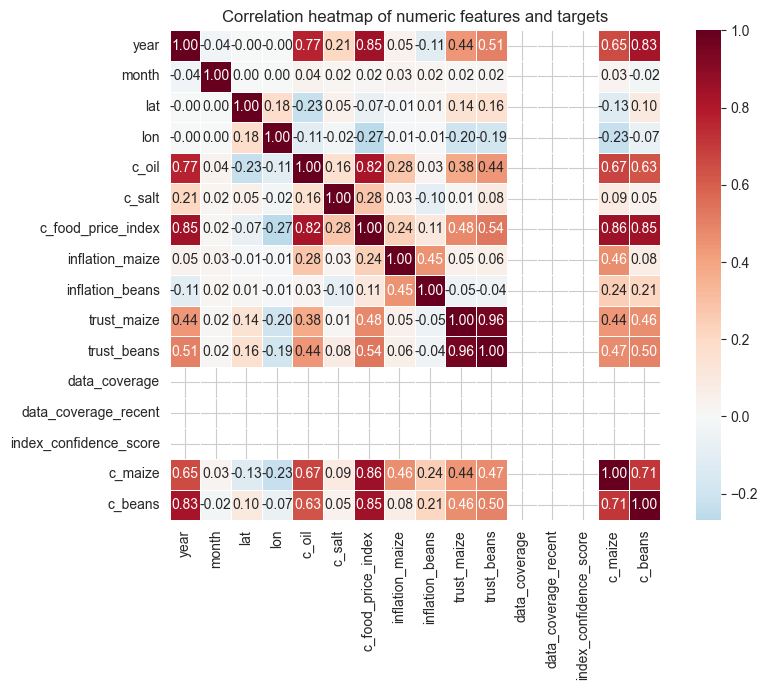

In [12]:
num_feats = [c for c in feature_cols if not c.startswith('mkt_name_')]
corr = df_model[num_feats + target_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation heatmap of numeric features and targets')
plt.tight_layout()
plt.show()

Maize and beans prices move together.  
Both also rise with the food-price index and with year.

### 9.2 PCA exploration and decision

PCA makes new combined featuees that preserve as much variation as possible in fewer columns. This code standardises the candidate features first, then checks how many components are needed to explain at least 95% of the variance. We use it to explore dimensionality; these components are not used in the final train/test arrays.

In [13]:
scaler_temp = StandardScaler()
X_temp = scaler_temp.fit_transform(df_model[feature_cols])

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_temp)

print(f"Original features: {len(feature_cols)}")
print(f"PCA components needed for 95% variance: {pca.n_components_}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

Original features: 20
PCA components needed for 95% variance: 10
Variance explained: 96.64%


**PCA result and decision:** PCA used 10 components to explain 96.64% of the variance in the 20 candidate features. We keep the original features because their names are easier to explain and the feature count is already small. This PCA ran is only an exploration; its transformed values are not used in the train/test features. If PCA is used in a model, fit it on training data only and apply that fitted transfoermation to test data (Scikit-learn developers, n.d.).

### 9.3 Class imbalance

Not applicable – this is a regression problem, not classification.

In [14]:
print("Problem type: Regression")
print("Class-imbalance handling: NOT APPLICABLE")

Problem type: Regression
Class-imbalance handling: NOT APPLICABLE


**Result:** Both targets are continuous prices, so this is regression. Class-balancing methods apply to class labels and are not needed here.

### 9.4 Train/test split and correct scaling

This code separates the selected features from the two price targets, then holds out 20% of the rows with a fixed random seed so the split can be repeated. It makes the same row split for both targets. This is a random holdout, not a test on later months; a true forecast check should hold out later dates.

In [15]:
X = df_model[feature_cols]
y_maize = df_model['c_maize']
y_beans = df_model['c_beans']

X_train, X_test, y_train_m, y_test_m = train_test_split(
    X, y_maize, test_size=0.2, random_state=42
)

_, _, y_train_b, y_test_b = train_test_split(
    X, y_beans, test_size=0.2, random_state=42
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows:     {X_test.shape[0]}")

Training rows: 1075
Test rows:     269


**Split result:** The table has 1,075 training rows and 269 test rows. The next cell compares Min–Max scaling. It fits the scaler on training rows first, then applies those same training limits to test rows.

In [16]:
# Compare Min-Max scaling using training data only
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

print("Min-Max scaler fitted on training data only.")
print(f"Training range: {X_train_minmax.min():.3f} to {X_train_minmax.max():.3f}")
print(f"Test range:     {X_test_minmax.min():.3f} to {X_test_minmax.max():.3f}")

Min-Max scaler fitted on training data only.
Training range: 0.000 to 1.000
Test range:     0.000 to 1.000


**Min–Max result:** The training features now range from 0 to 1. This test set also falls in that range, but new values outside the training range could fall outside 0–1. The next cell uses Z-score scaling: it subtracts each training feature's mean and divides by its standard deviation. This puts feature scales closer together, although large outliers can still affect the mean and standard deviation.

In [17]:
# Fit scaler ONLY on the training set (no data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaler fitted on training data only.")
print(f"Scaled training shape: {X_train_scaled.shape}")
print(f"Scaled test shape:     {X_test_scaled.shape}")

Scaler fitted on training data only.
Scaled training shape: (1075, 20)
Scaled test shape:     (269, 20)


---
## Stage 10: Exploratory Data Analysis (key charts)

We show the six categories listed in the lecture guide.

**Split and scaling result:** The 1,344-row table was split into 1,075 training rows and 269 test rows. The final scaled arrays have 20 features. The scaler was fitted on training rows only, then used on test rows.

This is a random row split, not a future-month test. Al seven market have a row for each month, so rows from the same month can appear in both sets. Do not use this split to claim future-forecast accuracy. A foreccast test should hold out later dates and use features available at the forecast date.

### 10.1 Descriptive statistics and skewness

This cell reports the count, mean, spread, quartiles and range for both target prices. It also calculates skewness. These numbers help us describe the price distributions and decide whether a log comparison is useful.

In [18]:
print(df_model[['c_maize', 'c_beans']].describe().round(2))
print("\nSkewness c_maize:", round(df_model['c_maize'].skew(), 2))
print("Skewness c_beans:", round(df_model['c_beans'].skew(), 2))

       c_maize  c_beans
count  1344.00  1344.00
mean   1094.27  2724.88
std     455.88  1056.48
min     407.41   956.57
25%     750.00  1916.54
50%    1000.00  2500.00
75%    1300.00  3392.11
max    2625.00  6557.42

Skewness c_maize: 1.15
Skewness c_beans: 0.8


**Statistics result:** Maize has a mean of 1,094.27 UGX/kg and a median of 1,000.00; beans has a mean of 2,724.88 and a median of 2,500.00. Their skew values are 1.15 and 0.80. The higher means fit the longer high-price tails seen in the charts. The next cell checks whether `log1p` reduces skew.

In [19]:
# Compare target skew before and after log1p; this is an EDA check only
original_skew = df_model[target_cols].skew()
log_skew = np.log1p(df_model[target_cols]).skew()

print("Target skew before and after log1p:")
for target in target_cols:
    print(f"{target}: {original_skew[target]:.2f} -> {log_skew[target]:.2f}")

Target skew before and after log1p:
c_maize: 1.15 -> 0.32
c_beans: 0.80 -> 0.04


The maize mean is 1,094.27 UGX/kg and its median is 1,000.00; its skew is 1.15. The beans mean is 2,724.88 UGX/kg and its median is 2,500.00; its skew is 0.80. Both distributions have a longer high-price tail. After `log1p`, the skew values are 0.32 for maize and 0.04 for beans. This makes the distributions more balanced in this check, but it does not prove that a log-price model will predict better. The final target columns remain in UGX.

### 10.2 Univariate  histograms and box plots

This code draws a histogram and a box plot for each target. Histograms show the shape of prices; box plots show the median, spread and values far from the middle. These views help us describe the targets before modelling.

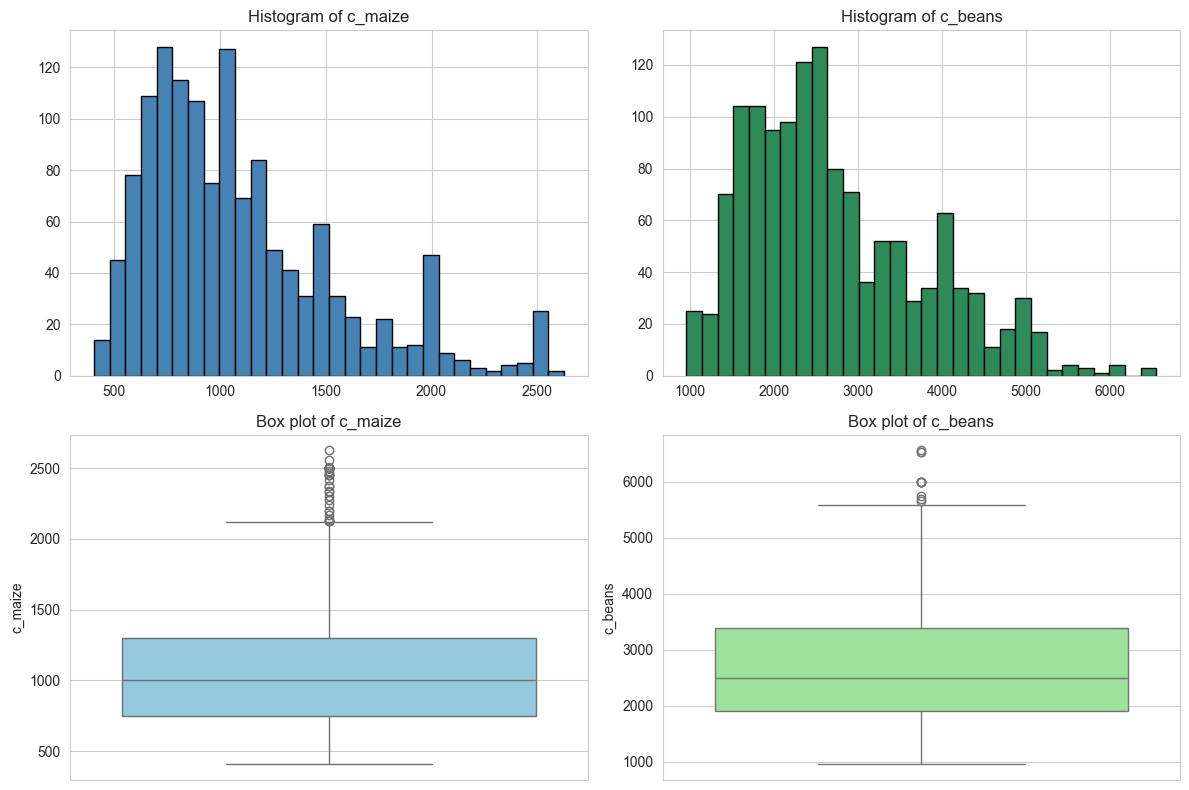

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df_model['c_maize'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Histogram of c_maize')

axes[0, 1].hist(df_model['c_beans'], bins=30, color='seagreen', edgecolor='black')
axes[0, 1].set_title('Histogram of c_beans')

sns.boxplot(y=df_model['c_maize'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Box plot of c_maize')

sns.boxplot(y=df_model['c_beans'], ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Box plot of c_beans')

plt.tight_layout()
plt.show()

**What these charts show:** Both price histograms have longer tails on the high-price side. The box plots show values beyond the whiskers, which are worth checking but are not automatically errors. The IQR counts above use the full 1,652-row table; these plots use the 1,344-row modelling table, so their point counts need not match.

### 10.3 Bivariate : scatter and yearly trend

The scatter plot compares maize and beans prices for the same rows. The line chart groups the prices by year and plots each year's average. These views help us see whether the prices move together and how the averages change over time; they do not prove cause.

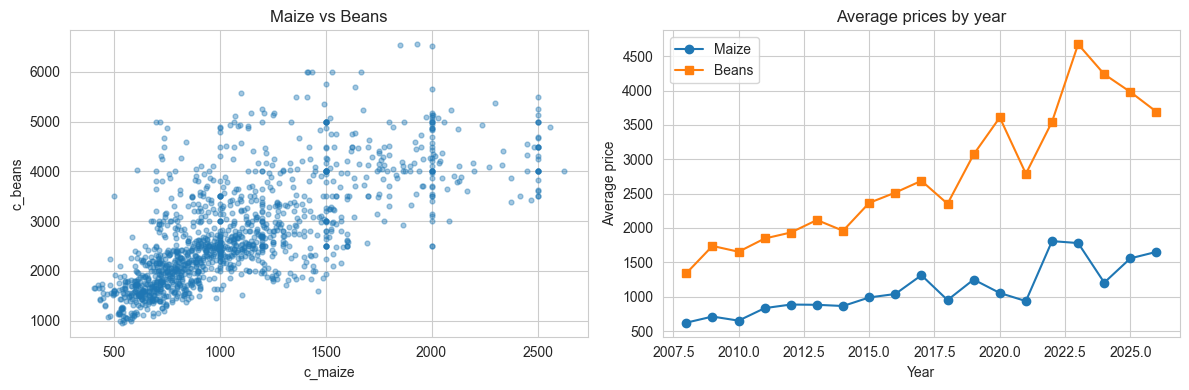

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df_model['c_maize'], df_model['c_beans'], alpha=0.4, s=12)
axes[0].set_xlabel('c_maize')
axes[0].set_ylabel('c_beans')
axes[0].set_title('Maize vs Beans')

yearly = df_model.groupby('year')[['c_maize', 'c_beans']].mean()
axes[1].plot(yearly.index, yearly['c_maize'], marker='o', label='Maize')
axes[1].plot(yearly.index, yearly['c_beans'], marker='s', label='Beans')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average price')
axes[1].set_title('Average prices by year')
axes[1].legend()

plt.tight_layout()
plt.show()

**What these charts show:** The scatter plot shows that higher maize prices often occur with higher beans prices in this dataset. The yearly averages also rise over much of the period. These are associations in the selected data; they do not show that one price causes the other or explain why prices changed.

### 10.4 Missing data bar chart (original observed columns)

This code calculates the percent of missing values in the original maize, beans, oil and salt columns, then draws a bar chart. The chart makes it easier to compare how complete the observed price fields are. It does not explain why the values are missing.

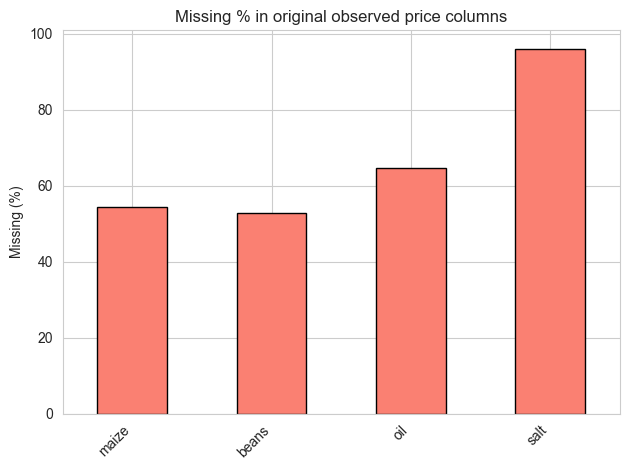

In [22]:
# Reload original market column for this check if needed
obs_cols = [c for c in ['maize', 'beans', 'oil', 'salt'] if c in df.columns]
if len(obs_cols) > 0:
    missing_pct = df[obs_cols].isnull().mean() * 100
    missing_pct.plot(kind='bar', color='salmon', edgecolor='black')
    plt.title('Missing % in original observed price columns')
    plt.ylabel('Missing (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Original observed columns not present in current table (already filtered).")

**Missing-data result:** The chart shows about 54.5% missing for observed maize, 52.7% for observed beans, 64.7% for oil, and 96.1% for salt. These values explain why the incomplete observed columns were not selected as model inputs. The completed target columns are separate estimates and have no missing values in this selected file.

### 10.5 Outlier visual: maize prices by year

The IQR rule flagged high maize values in the cleaning step. This chart places those values against year so we can see when they occur. A high value is not automatically an error or a confirmed market event; it needs context from the source data.

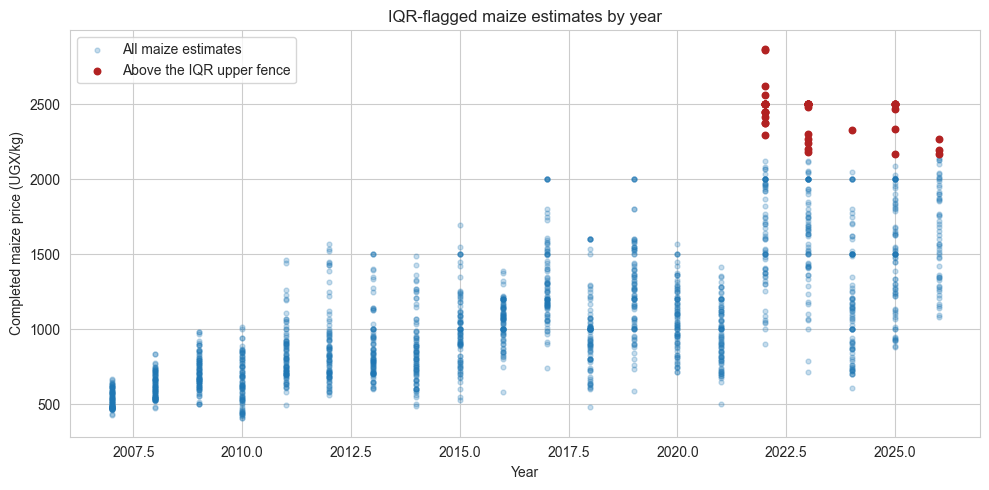

IQR upper fence: 2155.70 UGX/kg
Maize values above the fence: 48
Flagged values by year:
year
2022    19
2023    17
2024     1
2025     8
2026     3


In [23]:
maize_q1 = df['c_maize'].quantile(0.25)
maize_q3 = df['c_maize'].quantile(0.75)
maize_upper_fence = maize_q3 + 1.5 * (maize_q3 - maize_q1)
maize_flagged = df[df['c_maize'] > maize_upper_fence]

plt.figure(figsize=(10, 5))
plt.scatter(df['year'], df['c_maize'], alpha=0.25, s=12, label='All maize estimates')
plt.scatter(maize_flagged['year'], maize_flagged['c_maize'], color='firebrick', s=22,
            label='Above the IQR upper fence')
plt.xlabel('Year')
plt.ylabel('Completed maize price (UGX/kg)')
plt.title('IQR-flagged maize estimates by year')
plt.legend()
plt.tight_layout()
plt.show()

print(f"IQR upper fence: {maize_upper_fence:.2f} UGX/kg")
print(f"Maize values above the fence: {len(maize_flagged)}")
print("Flagged values by year:")
print(maize_flagged['year'].value_counts().sort_index().to_string())

**Result:** The upper fence is 2,155.70 UGX/kg, and 48 maize estimates are above it. The year counts show that 36 of the 48 flagged values are from 2022–2023; the other 12 are from 2024–2026. The flags are concentrated in recent years. This chart does not tell us why prices rose or whether an estimate is wrong, so we keep the values but do not call them confirmed market events.

### 10.6 Target variable analysis modelling implications

Both targets are continuous and right-skewed. The `log1p` check above reduces the skew in this sample, but a later model must be tested before we can say whether that helps. Mean absolute error can be reported in UGX/kg because it is on the target's original scale. There is no class imbalance to correct because these are regression targets.


The last code cell prints the array sizes and target counts. This is a final check that the prepared rows line up before any later model training.

In [24]:
print("=" * 50)
print("FULL PIPELINE BACKUP – ALL STAGES COMPLETE")
print("=" * 50)
print(f"Training features shape : {X_train_scaled.shape}")
print(f"Test features shape     : {X_test_scaled.shape}")
print(f"Maize train target size : {len(y_train_m)}")
print(f"Beans train target size : {len(y_train_b)}")
print("\nData is ready for modelling.")

FULL PIPELINE BACKUP – ALL STAGES COMPLETE
Training features shape : (1075, 20)
Test features shape     : (269, 20)
Maize train target size : 1075
Beans train target size : 1075

Data is ready for modelling.


**Final result:** The training array has 1,075 rows and 20 features; the test array has 269 rows and 20 features. Each training target has 1,075 values, matching the training rows. The data is prepared for a later model, but this notebook does not train one or measure forecast accuracy.

## References

- Andrée, B. P. J. (2021). *Monthly food price estimates by product and market* (Version 2026-08-24), UGA_2021_RTFP_v02_M. World Bank Microdata Library. [Dataset record and citation](https://doi.org/10.48529/2ZH0-JF55).
- Han, J., Kamber, M., & Pei, J. (2011). *Data mining: Concepts and techniques* (3rd ed.). Morgan Kaufmann.
- Tukey, J. W. (1977). *Exploratory data analysis*. Addison-Wesley.
- Scikit-learn developers. (n.d.). [Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html) and [principal component analysis](https://scikit-learn.org/stable/modules/decomposition.html#pca). Accessed October 1, 2026.

The explanations in this notebook summarize these sources in our own words. The dataset figures and statistics come from the local data and the code above.